In [ ]:
# Plots CDFs of RV and transiting planet occurrence rates

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
#file_name = '/Users/eckhartspalding/Documents/git.repos/misc/notebooks_for_development/exoplanet_archive_2025.09.11_22.21.15.csv'
file_name = '/Users/eckhartspalding/Documents/git.repos/misc/notebooks_for_development/transiting_planets_20251009.csv'

In [3]:
df = pd.read_csv(file_name, skiprows=104)

In [4]:
df.keys()

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [5]:
df = df.sort_values(by='sy_dist').reset_index(drop=True)


In [6]:
print(len(df))
print(df.loc[df['pl_name'] == 'K2-18 b'])

4389
     pl_name hostname  default_flag  sy_snum  sy_pnum discoverymethod  \
141  K2-18 b    K2-18             1        1        2         Transit   

     disc_year disc_facility              soltype  pl_controv_flag  ...  \
141       2015            K2  Published Confirmed                0  ...   

    sy_vmagerr2  sy_kmag  sy_kmagerr1  sy_kmagerr2  sy_gaiamag  \
141      -0.042    8.899        0.019       -0.019     12.4154   

     sy_gaiamagerr1  sy_gaiamagerr2   rowupdate  pl_pubdate  releasedate  
141        0.000502       -0.000502  2019-03-18     2018-06   2019-03-21  

[1 rows x 92 columns]


In [7]:
pd.set_option('display.max_rows', None)

print(df['st_spectype'])

0                    NaN
1                    NaN
2                 M1.0 V
3                 M2.5 V
4                    NaN
5                    NaN
6                    NaN
7                   M0 V
8                   M0 V
9                     M1
10                  M3 V
11                  M3 V
12                  M3 V
13                M1.5 V
14                M3.0 V
15                M3.5 V
16                   NaN
17                   NaN
18                   NaN
19                   M V
20                   NaN
21                    M5
22                M4.5 V
23                M4.5 V
24                M2.5 V
25                   NaN
26                  K4.5
27                  K4.5
28                   NaN
29                  m3 V
30                   NaN
31                   NaN
32                   NaN
33                M2.0 V
34                M2.0 V
35                M2.0 V
36                  K8 V
37                   NaN
38                    M3
39                   NaN


In [9]:
df = df.drop_duplicates(subset=['pl_name'])

In [10]:
df_rv = df.loc[df['discoverymethod'] == 'Radial Velocity']
df_transit = df.loc[df['discoverymethod'] == 'Transit']

In [14]:
list(df.keys())

['pl_name',
 'hostname',
 'pl_letter',
 'hd_name',
 'hip_name',
 'tic_id',
 'gaia_id',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'sy_mnum',
 'cb_flag',
 'discoverymethod',
 'disc_year',
 'disc_refname',
 'disc_pubdate',
 'disc_locale',
 'disc_facility',
 'disc_telescope',
 'disc_instrument',
 'rv_flag',
 'pul_flag',
 'ptv_flag',
 'tran_flag',
 'ast_flag',
 'obm_flag',
 'micro_flag',
 'etv_flag',
 'ima_flag',
 'dkin_flag',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_masse',
 'pl_masseerr1',
 'pl_masseerr2',
 'pl_masselim',
 'pl_massj',
 'pl_massjerr1',
 'pl_massjerr2',
 'pl_massjlim',
 'pl_msinie',
 'pl_msinieerr1',
 'pl_msinieerr2',
 'pl_msinielim',
 'pl_msinij',
 'pl_msinijerr1',
 'pl_msinijerr2',
 'pl_msinijlim',
 'pl_cmasse

In [23]:
len(df_rv)

1133

In [18]:
df['discoverymethod'][0]

'Radial Velocity'

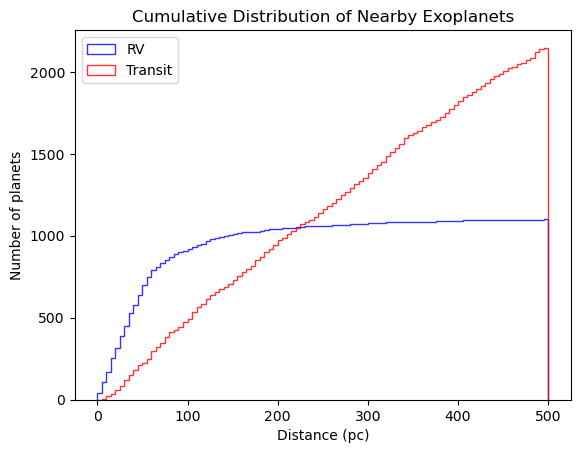

In [26]:
plt.hist(df_rv['sy_dist'], cumulative=True, bins=100, range=[0,500],
         histtype='step', alpha=0.8, color='blue', label='RV')
plt.hist(df_transit['sy_dist'], cumulative=True, bins=100, range=[0,500],
         histtype='step', alpha=0.8, color='red', label='Transit')
plt.ylabel('Number of planets')
plt.xlabel('Distance (pc)')
plt.title('Cumulative Distribution of Nearby Exoplanets')
plt.legend()
plt.savefig('junk.png', dpi=300)

In [27]:
file_name_2 = '/Users/eckhartspalding/Documents/git.repos/misc/notebooks_for_development/full_HPIC.txt'

In [30]:
df_hpic = pd.read_csv(file_name_2, delimiter='|')

In [34]:
list(df_hpic.keys())

['star_name',
 'ra',
 'dec',
 'ra_J2016',
 'dec_J2016',
 'tic_id',
 'gaia_dr2_id',
 'gaia_dr3_id',
 'hip_name',
 'tm_name',
 'tyc_name',
 'wds_designation',
 'simbad_name',
 'source_list_fl',
 'sy_pmra',
 'sy_pmraerr',
 'sy_pmdec',
 'sy_pmdecerr',
 'sy_pmsrc',
 'sy_pm_reflink',
 'sy_ujmag',
 'sy_ujmagerr',
 'sy_ujmagsrc',
 'sy_ujmag_reflink',
 'sy_bmag',
 'sy_bmagerr',
 'sy_bmagsrc',
 'sy_bmag_reflink',
 'sy_vmag',
 'sy_vmagerr',
 'sy_vmagsrc',
 'sy_vmag_reflink',
 'sy_rcmag',
 'sy_rcmagerr',
 'sy_rcmagsrc',
 'sy_rcmag_reflink',
 'sy_icmag',
 'sy_icmagerr',
 'sy_icmagsrc',
 'sy_icmag_reflink',
 'sy_jmag',
 'sy_jmagerr',
 'sy_jmagsrc',
 'sy_jmag_reflink',
 'sy_hmag',
 'sy_hmagerr',
 'sy_hmagsrc',
 'sy_hmag_reflink',
 'sy_kmag',
 'sy_kmagmerr',
 'sy_kmagsrc',
 'sy_kmag_reflink',
 'sy_tmag',
 'sy_tmagerr',
 'sy_gaiamag',
 'sy_gaiamagerr',
 'sy_gaiamagsrc',
 'sy_gaiamag_reflink',
 'sy_bpmag',
 'sy_bpmagerr',
 'sy_rpmag',
 'sy_rpmagerr',
 'sy_plx',
 'sy_plxerr',
 'sy_plxsrc',
 'sy_plx_refli

In [44]:
df_hpic['sy_dist'].sort_values().dropna()

3502      1.301911
7         1.347491
5         1.347491
2789      1.828106
12756     2.408358
           ...    
2667     49.992237
9410     49.992825
10774    49.995102
12496    49.996231
12615    49.998394
Name: sy_dist, Length: 12801, dtype: float64